# Data Preparation

The following code block reads the [CSV file for VCQ](https://raw.githubusercontent.com/qarnac/cs201/main/vcq_data_nan.csv) into a DataFrame object. It then creates a new DataFrame object to focus on questions from the Family Satisfaction section of the survey. It is important to run this code block before working on the rest of the notebook.
Refer to the [VCQ code book](https://docs.google.com/document/d/1uYfUuUsPVQyD3puVvbIMjamYuVPr_f4gtJuSB5Wj-WA/edit) for questions that match the columns in the following dataset.


In [1]:
#Collect data into a DataFrame object
import pandas as pd
raw_df = pd.read_csv('https://raw.githubusercontent.com/qarnac/cs201/main/vcq_data_nan.csv')

# Create a DataFrame object to hold only columns from the family satisfaction section
family_df = raw_df.filter(regex='^family').copy()
# Remove the family_ prefix
family_df.columns = family_df.columns.str.removeprefix('family_')
# Recode responses for negatively worded questions
r_columns = ['stress', 'secrets', 'fight']
family_df[r_columns] = 7 - family_df[r_columns]
# Create a column to hold the average among the columns
# Note that I didn't specify the columns before calling the mean function.
# This is because I want to use all columns in the dataset.
family_df['mean'] = family_df.mean(axis=1)

# Combine columns from multiple DataFrame

In [ ]:
#source of data: https://www.pewresearch.org/social-trends/2014/04/10/next-america/#the-generational-divide
import pandas as pd
population_data = {
    'Year':[1960, 1970, 1980, 1990, 2000, 2010, 2020, 2030, 2040, 2050, 2060],
    'White':[.85, .83, .80, .76, .69, .64, .60, .55, .51, .47, .43],
    'Black': [.10, .11, .12, .12, .12, .12, .13, .13, .13, .13, .13],
    'Hispanic': [.04, .05, .06, .09, .13, .16, .19, .22, .25, .28, .31],
    'Asian': [.01, .01, .02, .03, .04, .05, .06, .06, .07, .08, .08],
    'Others': [.00, .00, .01, .01, .02, .03, .03, .04, .04, .05, .06]
    }
population_df = pd.DataFrame(population_data)
population_df

In the above code block, we used a dictionary to specify data for the columns. We can use the same approach to create a new DataFrame using columns from existing DataFrame objects.

*  The text before each colon is the name for a column.
*  After each colon, we specify where each column will receive its values.

For example, in the following code block
*  The `'gender'` column in the new DataFrame object will receive its values from the `'demo_gender'` column of `raw_df`.
*  The `'family_satisfaction'` column in the new DataFrame object will receive its values from the `'mean'` column of `family_df`.

In [2]:
family_by_gender_data = {'gender':raw_df['demo_gender'].copy(),
                  'family_satisfaction':family_df['mean'].copy()}
family_by_gender_df = pd.DataFrame(family_by_gender_data)
pd.options.display.float_format = '{:.2f}'.format
family_by_gender_df.head()

,gender,family_satisfaction
0,1,4.29
1,2,4.86
2,1,5.14
3,2,4.71
4,2,4.43


## Practice

In [ ]:
# Create a DataFrame object to include data from family_df['mean']
# and two non-gender categorical columns from the demographics section


# The seaborn Library

The [`seaborn` library](https://seaborn.pydata.org/) is a third-party library built on top of `matplotlib` to provide a more streamlined, user-friendly interface for creating visually appealing and informative statistical graphics.

Due to its popularity in data science, Google Colab already includes the `seaborn` library in its environment. If you are running Python in an environment that does not already support this library, you will need to run the following to install it.

In [ ]:
!pip install seaborn
#Do not run this block since Google Colab already supports seaborn

It is important and common practice for developers to include the following `import` statement. This statement also helps developers to use `sns` as the abbreviation of `seaborn` when calling functions from the `seaborn` library.

In [ ]:
import seaborn as sns

# sns.histplot

Previously, we used `df.plot` to create histograms. The seaborn library also supports the creation of histogram. The name of the function is `histplot`. Here are some key parameters for the `histplot` function:

*  `data`: This identify the DataFrame object from data will be used to generate the histogram.
*  `x`: This identify the column for which the histogram is created.
*  `bins`: This is the same as the bins for `df.plot`, indicating the number of bins to be used. We can also use this parameter to set custom bins.
*  `kde`: When this is set to True, a smoothed estimate of the distribution will be drawn.

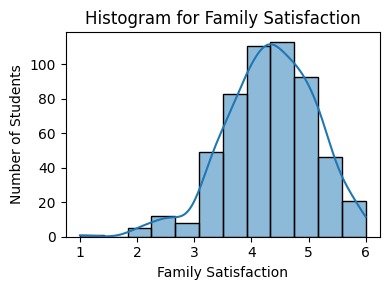

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 3))
plt.title('Histogram for Family Satisfaction')
plt.ylabel('Number of Students')
plt.xlabel('Family Satisfaction')

sns.histplot(data=family_by_gender_df, x='family_satisfaction', bins=12, kde=True)

plt.tight_layout()
plt.show()

The above histogram matches the histogram we previously created using `df.plot`. It shows that family satisfaction among the respondents follows a normal distribution, centered around 4.5 and slightly skewed to the right.

The `sns.histplot` function also supports a `hue` parameter that we can use to visualize the distribution of family satisfaction among different categories. When using a `hue` parameter, we can also specify a `palette` parameter to map categories into our colors of choice. Here are some built-in palettes:
*  colorblind: designed to be readable for color-vision deficiencies
*  deep: bold, high contrast, good for slides and projection
*  muted: softer than deep, easier on the eyes for print or long viewing
*  pastel: very light colors, nice for handouts but low constrast on projectors
*  bright: very saturated, can feel loud
*  Set1: Strong contrast
*  Set2: soft, distinct colors
*  Paired: colors come in pairs, useful when categories are naturally paired.

For example, in the following code block, we use `'family_satisfaction'` as the `x` parameter and `'gender'` as the `hue` parameter for `sns.histplot`. This creates three histograms in one figure, comparing the distribution of family satisfaction within each gender group.

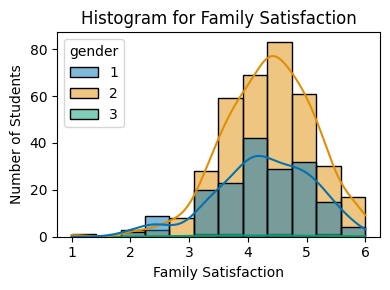

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use plt functions to set up the figure size, title, and labels
plt.figure(figsize=(4, 3))
plt.title('Histogram for Family Satisfaction')
plt.ylabel('Number of Students')
plt.xlabel('Family Satisfaction')

sns.histplot(data=family_by_gender_df,  # specify the DataFrame object
             x='family_satisfaction',   # identify a numeric column
             hue='gender',              # identify a categorical column
             palette='colorblind',      # specify the color palette to be used
             bins=12,                   # specify the number of bins
             kde=True)                  # to show the curve

plt.tight_layout()
plt.show()

By default, bars for the same bins are created in **layers** by `sns.histplot`, which could sometimes be difficult to read. We can change this by adjusting the `multiple` parameter of `histplot` to **'dodge'** so that the bars for the same age group but different political views will be shown side-by-side.

Run the following code block to see the result

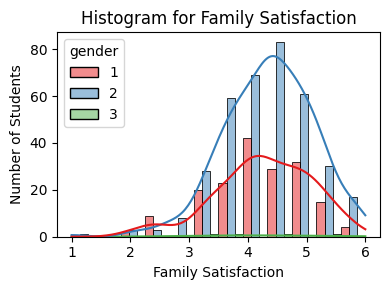

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 3))
plt.title('Histogram for Family Satisfaction')
plt.ylabel('Number of Students')
plt.xlabel('Family Satisfaction')

sns.histplot(data=family_by_gender_df,
             x='family_satisfaction',
             hue='gender',
             palette='Set1',
             multiple='dodge',    # Show bars of the same bin side-by-side
             bins=12,
             kde=True)

plt.tight_layout()
plt.show()

From the above histograms, we can see that there were many more female students than male students who completed the survey. The distributions are similar between the groups.

## Practice

In [ ]:
# Create one figure with multiple histograms to compare the distribution of family satisfaction
# among different values for one of the categorical columns in your dataset.


In [ ]:
# Create one figure with multiple histograms to compare the distribution of family satisfaction
# among different values for the other categorical columns in your dataset.


In a text block, write down your observation about the students based on the histograms.

# sns.boxplot

A boxplot (also called a box-and-whisker plot) is a visual summary of a dataset that shows:

*  The center (median)
*  The spread (range and interquartile range)
*  Outliers (unusual values)

It's especially useful for comparing distributions across groups.

## Overall boxplot for one numeric column

The following call to `sns.boxplot` specifies three parameters:

*  **data**: identify the DataFrame object from which data will be used.
*  **y**: identify the column whose values will be used to generate the boxplot.
*  **showmeans**: indicate whether to show the average/mean for the column.

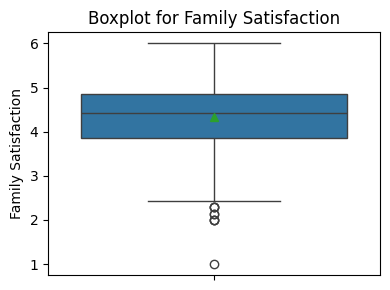

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 3))
plt.title('Boxplot for Family Satisfaction')
plt.ylabel('Family Satisfaction')

sns.boxplot(data=family_by_gender_df,
            y='family_satisfaction',
            showmeans=True)

plt.tight_layout()  #automatically adjusts the spacing of plot elements
plt.show()

The **Box** shows the interquartile range (IQR), which contains the middle 50% of the data.

*  Bottom of the box: First quartile (Q1, 25th percentile). In the above example, the value is a bit below 4.
*  Top of the box: Third quartile (Q3, 75th percentile). In the above example, the value is a bit below 5.
*  Line inside the box: Median (Q2, 50th percentile). In the above example, the value is around 4.5.
*  The triangle marker: indicates the average value.

The IQR is the difference between Q3 and Q1, reflected by the height of the box.

The **Whiskers** show the range of typical values.
*  Lower whisker: Extends from Q1 to the smallest value within 1.5 * IQR below Q1.
*  Upper whisker: Extends from Q3 to the largest value within 1.5 * IQR above Q3.

Any data points outside the whiskers are considered **outliers** These are often shown as dots or asterisks

## Add one categorical group

The sns.boxplot function allows us to add a categorical column using the x parameter to compare distribution of a numeric column among different categories.

In the following call to sns.boxplot,
*  The **data** parameter identifies the DataFrame object from which data will be used.
*  The **y** parameter identifies the column for which the box plots will be generated.
*  The **x** parameter identifies the categorical group to be used to split the box plots.
*  The **order** parameter allows us to specify the order of box plots to be listed on the x-axis.

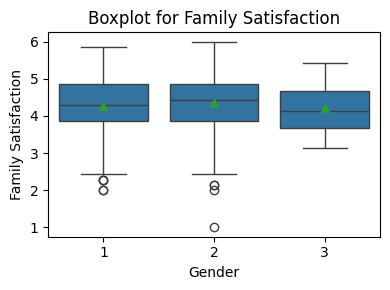

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 3))
plt.title('Boxplot for Family Satisfaction')
plt.ylabel('Family Satisfaction')
plt.xlabel('Gender')

sns.boxplot(data=family_by_gender_df,
            y='family_satisfaction',
            x='gender',
            showmeans=True)

plt.tight_layout()  #automatically adjusts the spacing of plot elements
plt.show()

Here are things we should pay attention when reading the above box plots.
1. Median/mean Comparison

Look at the line and triangle inside each box. Are all lines/triangle at the same height? It looks like the median/average for 1 (Male) is slightly lower than the median/triangle for 2 (Female). We know from earlier exploration that there are very few responses of 3 (Other). Therefore, statistics generated for that group are too sensitive to be generalized.

2. Spread of Data (IQR)

Compare the height of the boxes. A taller box means more variability in satisfaction. In the above result, the box for 1 (Male) is about the same height as the box for 2 (Female). This does not mean that we have the same number of male respondents and famle respondents.

3. Whiskers

Whiskers show the range of typical values. Again the ranges of typical values for both Male and Female are similar.

4. Outliers

Dots outside the whiskers are outliers. While each dot represents one value outside of the typical range, more than one student might share the same value.

## Practice

In [ ]:
# Create one figure with multiple boxplots to compare the distribution of family satisfaction
# among different values for one of the categorical columns in your dataset.


In [ ]:
# Create one figure with multiple boxplots to compare the distribution of family satisfaction
# among different values for the other categorical columns in your dataset.


**Add a text block** to make observations on the students' family satisfaction  based on the above box plots.

* Median comparison
* Spread of data
* Whiskers
* Outliers

# Practice

Complete the following tasks. You may use as many/few code blocks as you see fit.
*  Copy code from last class to create deviance_df, recode appropriate columns and determine the average deviance among related columns.
*  Create a new DataFrame object to include one categorical demographics column and the average deviance column.
*  Use sns.histplot to create histograms that compare the distribution of deviance among different categories.
*  Use sns.boxplot to create boxplots that compare the distribution of deviance among different categories.

Add a code block to explain what you learn about the data from the above histgrams and boxplots.